In [4]:
# Load the pizza sales dataset and do quick sanity checks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pizza_df = pd.read_csv('Pizzavv.csv')



In [9]:
pizza_df.head(5)
print("Initial Shape:", pizza_df.shape)

Initial Shape: (48620, 12)


## Data cleaning

In [10]:
# 3. Standardize Column Names
pizza_df.columns = pizza_df.columns.str.strip().str.lower().str.replace(" ", "_")

# 4. Check Missing Values
print("\n Missing Values:")
print(pizza_df.isnull().sum())



 Missing Values:
pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [11]:
df = pizza_df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (48620, 12)


## Exploratory data Analysis

In [14]:
pizza_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   pizza_id            48620 non-null  int64         
 1   order_id            48620 non-null  int64         
 2   pizza_name_id       48620 non-null  object        
 3   quantity            48620 non-null  int64         
 4   order_date          48620 non-null  datetime64[ns]
 5   order_time          48620 non-null  object        
 6   unit_price          48620 non-null  float64       
 7   total_price         48620 non-null  float64       
 8   pizza_size          48620 non-null  object        
 9   pizza_category      48620 non-null  object        
 10  pizza_ingredients   48620 non-null  object        
 11  pizza_name          48620 non-null  object        
 12  order_month         48620 non-null  object        
 13  order_day           48620 non-null  object    

## Descriptive Statistics (Summary Metrics)

In this section, we analyze the central tendency and dispersion of key numerical variables such as quantity, unit price, and total price.

In [15]:
# Select numerical columns
num_cols = ['quantity', 'unit_price', 'total_price']

# Mean
print("Mean:\n", df[num_cols].mean())

# Median
print("\nMedian:\n", df[num_cols].median())

# Mode
print("\nMode:\n", df[num_cols].mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:\n", df[num_cols].std())

Mean:
 quantity        1.019622
unit_price     16.494132
total_price    16.821474
dtype: float64

Median:
 quantity        1.0
unit_price     16.5
total_price    16.5
dtype: float64

Mode:
 quantity        1.00
unit_price     20.75
total_price    20.75
Name: 0, dtype: float64

Standard Deviation:
 quantity       0.143077
unit_price     3.621789
total_price    4.437398
dtype: float64


In [16]:
# Parse dates/times
pizza_df['order_date'] = pd.to_datetime(pizza_df['order_date'], errors='coerce')
pizza_df['order_time'] = pd.to_datetime(pizza_df['order_time'], format='%H:%M:%S', errors='coerce').dt.time

# Convert numeric columns
numeric_cols = ['quantity', 'unit_price', 'total_price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create useful time features
pizza_df['order_month'] = pizza_df['order_date'].dt.to_period('M').astype(str)
pizza_df['order_day'] = pizza_df['order_date'].dt.date
pizza_df['order_dow'] = pizza_df['order_date'].dt.day_name()
pizza_df['order_hour'] = pd.to_datetime(pizza_df['order_time'].astype(str), errors='coerce').dt.hour

# Basic computed metrics
pizza_df['line_revenue_check'] = pizza_df['unit_price'] * pizza_df['quantity']

print(pizza_df.head())
print(pizza_df[['total_price','line_revenue_check']].head())
print(pizza_df.shape)
print(pizza_df['order_date'].min())
print(pizza_df['order_date'].max())

C:\Users\USER\AppData\Local\Temp\ipykernel_7368\62927378.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pizza_df['order_hour'] = pd.to_datetime(pizza_df['order_time'].astype(str), errors='coerce').dt.hour


   pizza_id  order_id  pizza_name_id  quantity order_date order_time  \
0         1         1     hawaiian_m         1 2015-01-01   11:38:36   
1         2         2  classic_dlx_m         1 2015-01-01   11:57:40   
2         3         2  five_cheese_l         1 2015-01-01   11:57:40   
3         4         2    ital_supr_l         1 2015-01-01   11:57:40   
4         5         2     mexicana_m         1 2015-01-01   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2  Mozzarella Cheese, Provolone Cheese, Smoked Go...   
3  Cal

## Created core Aggregation and computed key business views

   order_id order_date order_dow  order_hour  order_revenue  pizzas
0         1 2015-01-01  Thursday          11          13.25       1
1         2 2015-01-01  Thursday          11          92.00       5
2         3 2015-01-01  Thursday          12          37.25       2
3         4 2015-01-01  Thursday          12          16.50       1
4         5 2015-01-01  Thursday          12          16.50       1


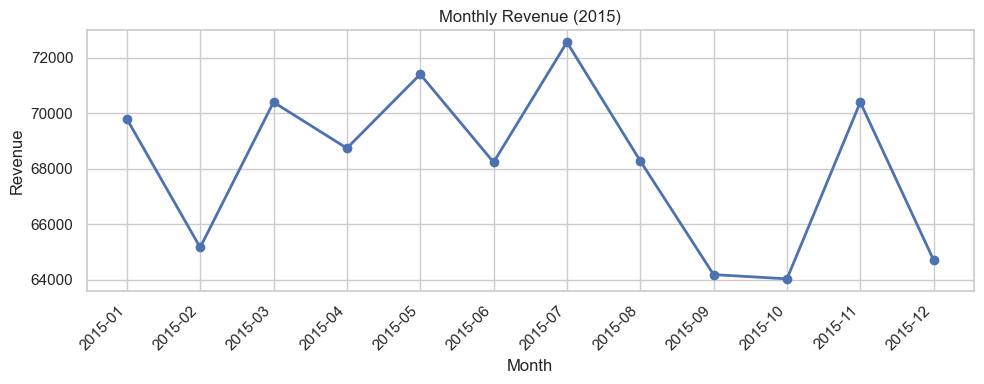

C:\Users\USER\AppData\Local\Temp\ipykernel_7368\571887571.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='pizza_category', y='revenue', palette='viridis')


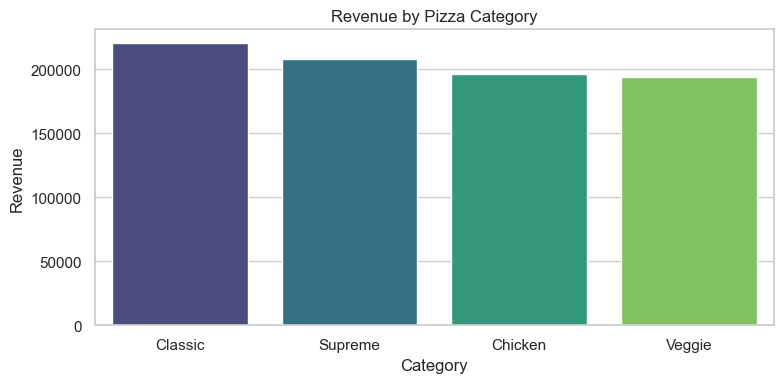

C:\Users\USER\AppData\Local\Temp\ipykernel_7368\571887571.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_df, x='pizza_size', y='revenue', palette='magma')


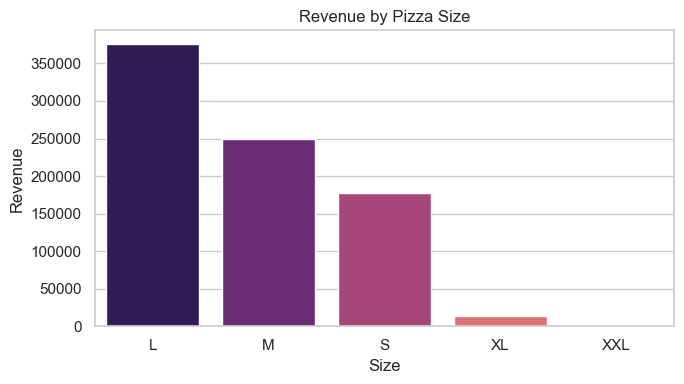

C:\Users\USER\AppData\Local\Temp\ipykernel_7368\571887571.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pizza_rev, y='pizza_name', x='revenue', palette='Blues_r')


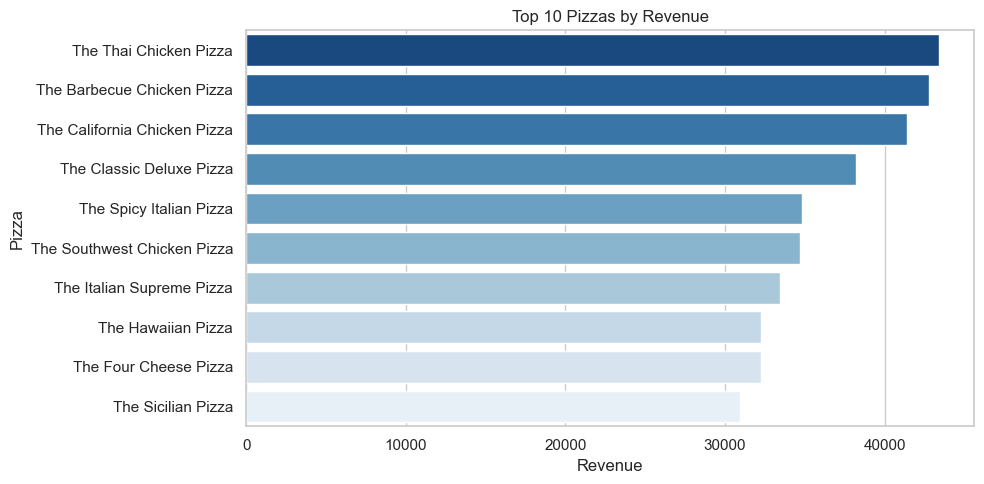

C:\Users\USER\AppData\Local\Temp\ipykernel_7368\571887571.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_order_df, x='order_dow', y='orders', palette='cubehelix')


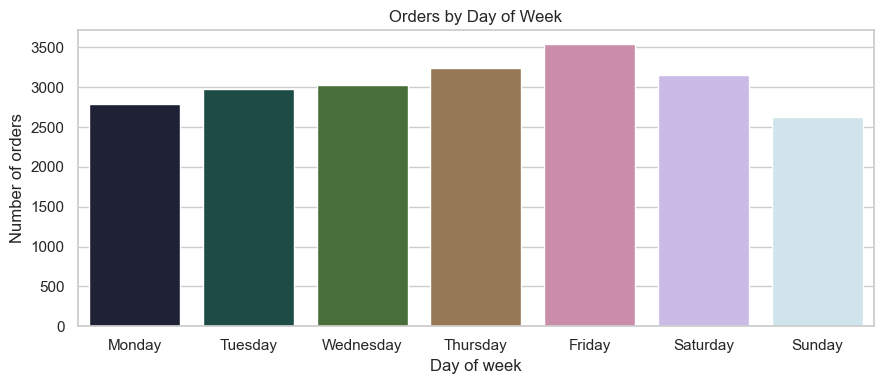

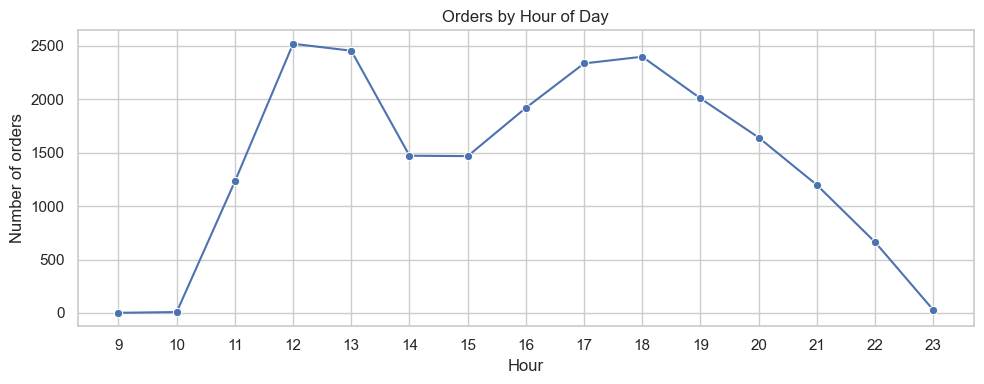

  pizza_category    revenue  quantity
1        Classic  220053.10     14888
2        Supreme  208197.00     11987
0        Chicken  195919.50     11050
3         Veggie  193690.45     11649
  pizza_size    revenue  quantity
0          L  375318.70     18956
1          M  249382.25     15635
2          S  178076.50     14403
3         XL   14076.00       552
4        XXL    1006.60        28
                      pizza_name   revenue  quantity
30        The Thai Chicken Pizza  43434.25      2371
0     The Barbecue Chicken Pizza  42768.00      2432
4   The California Chicken Pizza  41409.50      2370
7       The Classic Deluxe Pizza  38180.50      2453
26       The Spicy Italian Pizza  34831.25      1924
25   The Southwest Chicken Pizza  34705.75      1917
14     The Italian Supreme Pizza  33476.75      1884
12            The Hawaiian Pizza  32273.25      2422
9          The Four Cheese Pizza  32265.70      1902
23            The Sicilian Pizza  30940.50      1938
                      p

In [17]:
# Create core aggregations for visuals (revenue, quantity, orders) and plot key business views
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Fix the earlier parsing artifact for order_time (it picked today's date). Rebuild hour directly from the original string.
pizza_df['order_hour'] = pd.to_datetime(pizza_df['order_time'].astype(str), format='%H:%M:%S', errors='coerce').dt.hour

# Revenue and quantity
pizza_df['revenue'] = pizza_df['total_price']

# Order-level table
orders_df = (pizza_df.groupby('order_id', as_index=False)
             .agg(order_date=('order_date','first'),
                  order_dow=('order_dow','first'),
                  order_hour=('order_hour','first'),
                  order_revenue=('revenue','sum'),
                  pizzas=('quantity','sum')))

print(orders_df.head())

# Daily revenue series
daily_df = (pizza_df.groupby('order_day', as_index=False)
            .agg(revenue=('revenue','sum'),
                 quantity=('quantity','sum'),
                 orders=('order_id','nunique'))
            .sort_values('order_day'))

# Monthly revenue
monthly_df = (pizza_df.groupby('order_month', as_index=False)
              .agg(revenue=('revenue','sum'),
                   quantity=('quantity','sum'),
                   orders=('order_id','nunique'))
              .sort_values('order_month'))

# Category and size
cat_df = (pizza_df.groupby('pizza_category', as_index=False)
          .agg(revenue=('revenue','sum'), quantity=('quantity','sum'))
          .sort_values('revenue', ascending=False))

size_df = (pizza_df.groupby('pizza_size', as_index=False)
           .agg(revenue=('revenue','sum'), quantity=('quantity','sum'))
           .sort_values('revenue', ascending=False))

# Top pizzas
top_pizza_rev = (pizza_df.groupby('pizza_name', as_index=False)
                 .agg(revenue=('revenue','sum'), quantity=('quantity','sum'))
                 .sort_values('revenue', ascending=False)
                 .head(10))

top_pizza_qty = (pizza_df.groupby('pizza_name', as_index=False)
                 .agg(quantity=('quantity','sum'), revenue=('revenue','sum'))
                 .sort_values('quantity', ascending=False)
                 .head(10))

# DOW / hour patterns (order count and revenue)
dow_order_df = orders_df.groupby('order_dow', as_index=False).agg(orders=('order_id','count'), revenue=('order_revenue','sum'))
# Order day names to a natural order
order_dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_order_df['order_dow'] = pd.Categorical(dow_order_df['order_dow'], categories=order_dow_order, ordered=True)
dow_order_df = dow_order_df.sort_values('order_dow')

hour_df = orders_df.groupby('order_hour', as_index=False).agg(orders=('order_id','count'), revenue=('order_revenue','sum'))

# --- Plots ---
# 1) Monthly revenue trend
plt.figure(figsize=(10,4))
plt.plot(monthly_df['order_month'], monthly_df['revenue'], marker='o', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue (2015)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# 2) Category revenue
plt.figure(figsize=(8,4))
sns.barplot(data=cat_df, x='pizza_category', y='revenue', palette='viridis')
plt.title('Revenue by Pizza Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# 3) Size revenue
plt.figure(figsize=(7,4))
sns.barplot(data=size_df, x='pizza_size', y='revenue', palette='magma')
plt.title('Revenue by Pizza Size')
plt.xlabel('Size')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# 4) Top 10 pizzas by revenue
plt.figure(figsize=(10,5))
sns.barplot(data=top_pizza_rev, y='pizza_name', x='revenue', palette='Blues_r')
plt.title('Top 10 Pizzas by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Pizza')
plt.tight_layout()
plt.show()

# 5) Orders by day of week
plt.figure(figsize=(9,4))
sns.barplot(data=dow_order_df, x='order_dow', y='orders', palette='cubehelix')
plt.title('Orders by Day of Week')
plt.xlabel('Day of week')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

# 6) Orders by hour
plt.figure(figsize=(10,4))
sns.lineplot(data=hour_df, x='order_hour', y='orders', marker='o')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of orders')
plt.xticks(range(int(hour_df['order_hour'].min()), int(hour_df['order_hour'].max())+1))
plt.tight_layout()
plt.show()

# Print a few summary tables for insight extraction
print(cat_df)
print(size_df)
print(top_pizza_rev)
print(top_pizza_qty)